In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

In [2]:
df = pd.read_csv(r"C:\Users\91834\Downloads\weatherAUS_.csv")

In [3]:
df.head()

,Date,Location,MinTemp,MaxTemp,Rainfall,WindGustDir,WindGustSpeed,WindDir9am,WindDir3pm,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,RainToday,RainTomorrow
0,2011-11-08,Portland,14.1,22.1,5.4,WNW,50.0,NNW,S,20.0,11.0,97.0,75.0,1009.0,1008.8,Yes,No
1,2013-12-09,Adelaide,16.3,20.4,2.0,W,57.0,SW,WSW,13.0,28.0,90.0,46.0,1009.0,1009.1,Yes,Yes
2,2013-05-25,CoffsHarbour,13.6,19.9,147.8,SW,61.0,SW,SSW,46.0,31.0,53.0,50.0,1019.9,1020.6,Yes,No
3,2015-03-30,MountGinini,5.9,13.0,0.0,SSW,24.0,N,WSW,6.0,11.0,62.0,56.0,NaN,NaN,No,No
4,2016-03-09,Nhil,22.5,31.7,1.8,N,46.0,S,S,20.0,22.0,64.0,38.0,1015.2,1015.2,Yes,Yes


In [4]:
df.shape

(66410, 17)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 66410 entries, 0 to 66409
Data columns (total 17 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Date           66410 non-null  str    
 1   Location       66410 non-null  str    
 2   MinTemp        66080 non-null  float64
 3   MaxTemp        66269 non-null  float64
 4   Rainfall       65506 non-null  float64
 5   WindGustDir    61779 non-null  str    
 6   WindGustSpeed  61813 non-null  float64
 7   WindDir9am     61896 non-null  str    
 8   WindDir3pm     64472 non-null  str    
 9   WindSpeed9am   65735 non-null  float64
 10  WindSpeed3pm   65112 non-null  float64
 11  Humidity9am    65483 non-null  float64
 12  Humidity3pm    64611 non-null  float64
 13  Pressure9am    59863 non-null  float64
 14  Pressure3pm    59853 non-null  float64
 15  RainToday      65506 non-null  str    
 16  RainTomorrow   66410 non-null  str    
dtypes: float64(10), str(7)
memory usage: 10.5 MB


In [6]:
df.describe()

,MinTemp,MaxTemp,Rainfall,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm
count,66080.000000,66269.000000,65506.000000,61813.000000,65735.000000,65112.00000,65483.000000,64611.000000,59863.000000,59853.000000
mean,12.504429,22.512310,3.607192,41.954654,14.509013,19.11001,71.859414,57.223522,1016.594609,1014.302934
std,6.389136,7.119384,10.926853,14.626166,9.175109,9.17270,18.688560,21.802328,7.340833,7.272805
min,-8.500000,-4.100000,0.000000,6.000000,0.000000,0.00000,1.000000,0.000000,980.500000,977.100000
25%,7.900000,17.200000,0.000000,31.000000,7.000000,13.00000,60.000000,42.000000,1011.800000,1009.400000
50%,12.200000,21.800000,0.000000,39.000000,13.000000,19.00000,73.000000,58.000000,1016.600000,1014.300000
75%,17.200000,27.500000,2.200000,50.000000,20.000000,24.00000,87.000000,73.000000,1021.500000,1019.200000
max,31.200000,47.300000,371.000000,135.000000,87.000000,87.00000,100.000000,100.000000,1040.600000,1038.400000


In [7]:
df.isna().sum().sum()

np.int64(35762)

In [8]:
df.isna().sum()/len(df)*100

Date             0.000000
Location         0.000000
MinTemp          0.496913
MaxTemp          0.212317
Rainfall         1.361241
WindGustDir      6.973347
WindGustSpeed    6.922150
WindDir9am       6.797169
WindDir3pm       2.918235
WindSpeed9am     1.016413
WindSpeed3pm     1.954525
Humidity9am      1.395874
Humidity3pm      2.708929
Pressure9am      9.858455
Pressure3pm      9.873513
RainToday        1.361241
RainTomorrow     0.000000
dtype: float64

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df["RainTomorrow"].value_counts()

RainTomorrow
No     34533
Yes    31877
Name: count, dtype: int64

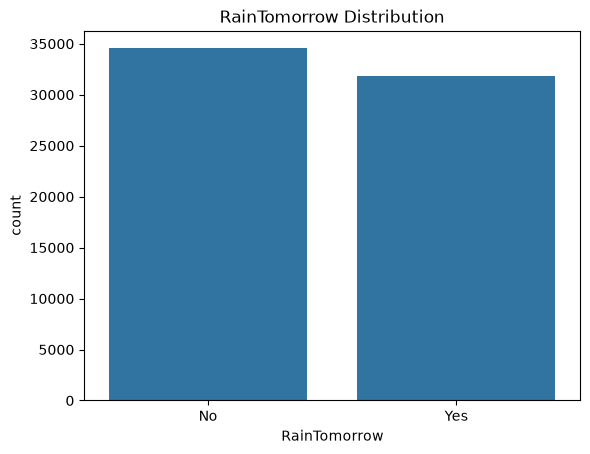

In [11]:
sns.countplot(x="RainTomorrow", data=df)
plt.title("RainTomorrow Distribution")
plt.show()

In [12]:
df = df.dropna(subset=["RainTomorrow"])

In [13]:
df["RainTomorrow"] = df["RainTomorrow"].map({"No": 0,"Yes": 1})

In [14]:
df["Date"] = pd.to_datetime(df["Date"])

df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Day"] = df["Date"].dt.day

In [15]:
df.drop("Date", axis=1, inplace=True)

In [16]:
X = df.drop("RainTomorrow", axis=1)
y = df["RainTomorrow"]

In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [19]:
numerical_columns = X_train.select_dtypes(include=np.number).columns
categorical_columns = X_train.select_dtypes(exclude=np.number).columns

In [20]:
numerical_columns

Index(['MinTemp', 'MaxTemp', 'Rainfall', 'WindGustSpeed', 'WindSpeed9am',
       'WindSpeed3pm', 'Humidity9am', 'Humidity3pm', 'Pressure9am',
       'Pressure3pm', 'Year', 'Month', 'Day'],
      dtype='str')

In [21]:
categorical_columns

Index(['Location', 'WindGustDir', 'WindDir9am', 'WindDir3pm', 'RainToday'], dtype='str')

In [22]:
for column in numerical_columns:
    mean_value = X_train[column].mean()
    
    X_train[column] = X_train[column].fillna(mean_value)
    X_test[column] = X_test[column].fillna(mean_value)

In [23]:
for column in categorical_columns:
    mode_value = X_train[column].mode()[0]
    
    X_train[column] = X_train[column].fillna(mode_value)
    X_test[column] = X_test[column].fillna(mode_value)

In [29]:
X_train = pd.get_dummies(X_train, drop_first=True)
X_test = pd.get_dummies(X_test, drop_first=True)

X_test = X_test.reindex(columns=X_train.columns, fill_value=0)


In [30]:
X_train.shape
X_test.shape

(13282, 107)

In [32]:
# Select only numerical columns for outlier detection

numeric_data = X_train.select_dtypes(include=np.number)

Q1 = numeric_data.quantile(0.25)
Q3 = numeric_data.quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = ((numeric_data < lower_bound) | 
            (numeric_data > upper_bound)).sum()

In [33]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [34]:
model = LogisticRegression(
    random_state=42,
)

In [35]:
model.fit(X_train_scaled, y_train)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solve

In [37]:
y_pred = model.predict(X_test_scaled)

In [38]:
y_prob = model.predict_proba(X_test_scaled)[:, 1]

In [39]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.7796265622647192


In [42]:
precision = precision_score(y_test, y_pred)

print('precision:',precision)

precision: 0.7887772194304857


In [43]:
recall = recall_score(y_test, y_pred)

print("Recall:", recall)

Recall: 0.7386666666666667


In [44]:
f1 = f1_score(y_test, y_pred)

print("F1 Score:", f1)

F1 Score: 0.7628999594977723


In [45]:
roc_auc = roc_auc_score(y_test, y_prob)

print("ROC-AUC:", roc_auc)

ROC-AUC: 0.8636091035806244


In [46]:
roc_auc = roc_auc_score(y_test, y_prob)

print("ROC-AUC:", roc_auc)

ROC-AUC: 0.8636091035806244


In [47]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.77      0.82      0.79      6907
           1       0.79      0.74      0.76      6375

    accuracy                           0.78     13282
   macro avg       0.78      0.78      0.78     13282
weighted avg       0.78      0.78      0.78     13282



In [48]:
results = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC"
    ],
    "Score": [
        accuracy,
        precision,
        recall,
        f1,
        roc_auc
    ]
})

results

,Metric,Score
0,Accuracy,0.779627
1,Precision,0.788777
2,Recall,0.738667
3,F1 Score,0.762900
4,ROC-AUC,0.863609
